<a href="https://colab.research.google.com/github/kavyaayyappan1998/DATA266---2738/blob/main/Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 4 — Building a Mini GPT from Scratch

In [1]:
from google.colab import files
uploaded = files.upload()

Saving shakespeare.txt to shakespeare.txt


The dataset is loaded from `shakespeare.txt`.

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

DATA_PATH = Path("shakespeare.txt")
if not DATA_PATH.exists():
    DATA_PATH = Path(next(iter(uploaded)))

text = DATA_PATH.read_text(encoding="utf-8")
print("Characters:", len(text))

Device: cuda
Characters: 1738


Part 1 — Data Preparation

Each character is one token. The target sequence is the input shifted by one character.

In [3]:
chars = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
tokens = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)

print("Vocabulary size:", len(chars))

SEQ_LEN = 128
STRIDE = 1

class TextDataset(Dataset):
    def __init__(self, tokens):
        self.tokens = tokens
        self.starts = range(0, len(tokens) - SEQ_LEN - 1, STRIDE)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        s = self.starts[i]
        return self.tokens[s:s+SEQ_LEN], self.tokens[s+1:s+SEQ_LEN+1]

dataset = TextDataset(tokens)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Training samples:", len(dataset))
print("Batches per epoch:", len(loader))

for i in range(2):
    x, y = dataset[i]
    print("\nINPUT:\n", "".join(idx_to_char[n.item()] for n in x))
    print("\nTARGET:\n", "".join(idx_to_char[n.item()] for n in y))

Vocabulary size: 49
Training samples: 1609
Batches per epoch: 51

INPUT:
 ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the 

TARGET:
 OMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e

INPUT:
 OMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the e

TARGET:
 MEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the en


Part 2 — GPT Architecture

Attention uses `softmax(QKᵀ / √d_head)V`. The causal mask blocks future characters so each position only sees the current and previous characters.

In [4]:
class MultiHeadMaskedAttention(nn.Module):
    def __init__(self, d_model=128, heads=4):
        super().__init__()
        assert d_model % heads == 0
        self.heads = heads
        self.head_dim = d_model // heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape

        q = self.q(x).view(B, T, self.heads, self.head_dim).transpose(1, 2)
        k = self.k(x).view(B, T, self.heads, self.head_dim).transpose(1, 2)
        v = self.v(x).view(B, T, self.heads, self.head_dim).transpose(1, 2)

        scores = q @ k.transpose(-2, -1) / (self.head_dim ** 0.5)

        # Do not look at future characters.
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        weights = torch.softmax(scores, dim=-1)
        out = weights @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out(out)


class DecoderBlock(nn.Module):
    def __init__(self, d_model=128, heads=4):
        super().__init__()
        self.attn = MultiHeadMaskedAttention(d_model, heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.ln1(x + self.attn(x))
        x = self.ln2(x + self.ff(x))
        return x

In [5]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, heads=4, layers=2):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(SEQ_LEN, d_model)
        self.blocks = nn.Sequential(*[
            DecoderBlock(d_model, heads) for _ in range(layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        T = x.size(1)
        pos = torch.arange(T, device=x.device)
        x = self.token_emb(x) + self.pos_emb(pos)
        x = self.blocks(x)
        return self.output(self.ln(x))

D_MODEL = 128
HEADS = 4
LAYERS = 2

model = MiniGPT(len(chars), D_MODEL, HEADS, LAYERS).to(device)

print("Total parameters:", sum(p.numel() for p in model.parameters()))
print("Hidden dimension:", D_MODEL)
print("Number of heads:", HEADS)
print("Number of layers:", LAYERS)

Total parameters: 425777
Hidden dimension: 128
Number of heads: 4
Number of layers: 2


Part 3 — Training

The model is trained with Adam for 6 epochs. Training loss is recorded after each epoch.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
EPOCHS = 6
losses = []

for epoch in range(EPOCHS):
    model.train()
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits.reshape(-1, len(chars)), y.reshape(-1))
        loss.backward()
        optimizer.step()
        total += loss.item()

    avg_loss = total / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

Epoch 1/6 - Loss: 2.6074
Epoch 2/6 - Loss: 2.1159
Epoch 3/6 - Loss: 1.9045
Epoch 4/6 - Loss: 1.5586
Epoch 5/6 - Loss: 1.1161
Epoch 6/6 - Loss: 0.6779


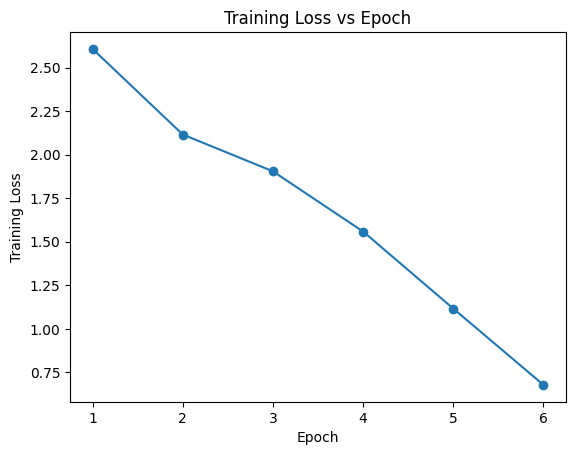

In [7]:
plt.plot(range(1, EPOCHS + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.show()

Part 4 — Text Generation

Greedy always picks the most likely next character. Temperature changes randomness, while top-k samples only from the `k` most likely choices.

In [8]:
@torch.no_grad()
def generate(prompt, max_new=300, method="greedy", temperature=1.0, k=20):
    model.eval()
    ids = torch.tensor([[char_to_idx[c] for c in prompt]], device=device)

    for _ in range(max_new):
        logits = model(ids[:, -SEQ_LEN:])[:, -1, :]

        if method == "greedy":
            next_id = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature

            if method == "topk":
                values, indices = torch.topk(logits, k)
                pick = torch.multinomial(torch.softmax(values, dim=-1), 1)
                next_id = indices.gather(1, pick)
            else:
                next_id = torch.multinomial(torch.softmax(logits, dim=-1), 1)

        ids = torch.cat([ids, next_id], dim=1)

    return "".join(idx_to_char[i] for i in ids[0].tolist())

In [9]:
prompt = "ROMEO:"

print("GREEDY\n")
print(generate(prompt, method="greedy"))

for t in [0.5, 1.0, 1.5]:
    print(f"\nTEMPERATURE = {t}\n")
    print(generate(prompt, method="temperature", temperature=t))

for k in [5, 40]:
    print(f"\nTOP-K = {k}\n")
    print(generate(prompt, method="topk", k=k))

GREEDY

ROMEO:
By a name
I knot how to to to to telde we we wear whe ro wo whe wo weard,
Tart thoul smyse and sweather sin shat wofull mat in an the the is madysenthick we
Soult it swe se it stull it it;
Sono their sm, st sheady thers shereall en,
Rome wher her her her her her wid, spes tes theyes
Taks the the wo

TEMPERATURE = 0.5

ROMEO:
By a name
I knot how tor to to to thy fatell thee an.

ROMEO:
By name! that or that wor whe? thy or whee!
What at’d w what whichict we wed she nat we
Wis whout thoult thy an.

What’t mame, Monose?
What is at thicke? is and no nat shat shat par pake
Bell aus aos aonot to madyse weld wet wet weakeat 

TEMPERATURE = 1.0

ROMEO:
SO:
O:
Shat thall I thee for wor any whird, shough Romeord fot ffat o that or pulet;
Herf bercart ison lovet beovesin but soveslre.

ady bond nome, ’t lo tha n.
Ber sher sher I wildy no nother Ron?

? whomeameamef caMrt to cainge, of d, co iste, nat, ist ist istefuefan te.
Noout par fairt faris nor

TEMPERATURE = 1.5

ROMEO:
And 

Part 5 — Short Analysis:

*   Greedy decoding - always picks the character with the highest score. It never takes a risk, so the text stays clean. My sample starts with "ROMEO: / By a name / I kno[t] how to...", which is close to the real text. But greedy gets stuck. You can see it repeat "to to to to", "her her her her her" and "it it;". Once it enters a loop, it has no way out.
*   Temperature sampling -  divides the scores by T before the softmax. At T=0.5 the model is more confident, so the text looks like greedy but without the loops. At T=1.0 it uses its normal probabilities. At T=1.5 everything flattens out, so rare characters can get picked. The words break down here, like "zewhout'll mais at ase" and "bofWidy dyst?".

*   Top-k sampling -  only keeps the top k characters and ignores the rest. This stops the model from ever picking something really bad. My vocabulary is 49 characters, so k=5 keeps only about 10% and is a strong limit. But k=40 keeps about 82%, which is almost no limit at all. So k only means something compared to the vocabulary size.

*   Most coherent: greedy - It never picks a low-probability character, so the
spelling stays the best. Top-k=5 is a close second, and it actually reads better
because it does not get trapped in loops.

*   Most diverse: temperature 1.5 -  It can use the whole vocabulary and the
probabilities are flattened, so it explores the most. So there is a trade-off. Anything that adds diversity does it by allowing weaker characters, and those are the ones that ruin the spelling.

*   Note on the dataset - The file is only about 1,738 characters, but the model has 425,777 parameters. That means the model mostly memorises this passage instead of really learning Shakespeare. The final loss of 0.68 looks low, but a random model would score ln(49) is 3.89, so this only shows it fits this one excerpt well.